In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
plt.style.use("ggplot")


In [4]:

data = pd.read_csv("../data/telco_customer_churn_clean.csv")

In [5]:
pd.set_option("display.max_columns", None)

In [7]:
data.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [8]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null   str    
 17  Paymen

How many customers churn?

In [10]:
data["Churn"].value_counts()

Churn
No     5174
Yes    1869
Name: count, dtype: int64

In [12]:
data["Churn"].value_counts(normalize=True) * 100

Churn
No     73.463013
Yes    26.536987
Name: proportion, dtype: float64

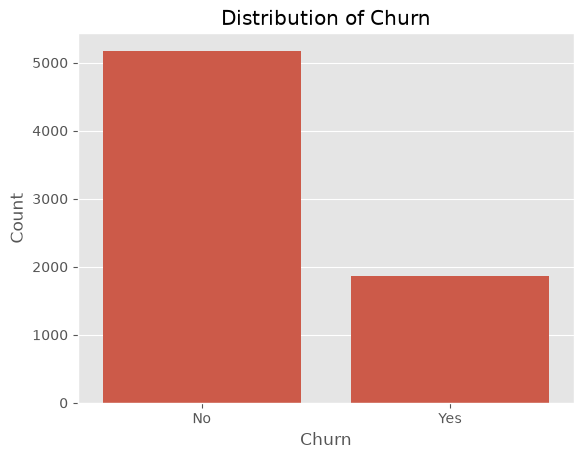

In [13]:
plt.Figure(figsize=(6, 4))
sns.countplot(x="Churn", data=data)
plt.title("Distribution of Churn")
plt.xlabel("Churn")
plt.ylabel("Count")
plt.show()


Most of the customer don't churn but ~27% customer churned.

dataset is midly imbalanced but will not balance it for now untill 1st model evaluation

Q. Do customers who stay longer with the company churn less?

In [14]:
data.groupby("Churn")['tenure'].describe()

,count,mean,std,min,25%,50%,75%,max
Churn,,,,,,,,
No,5174.0,37.569965,24.113777,0.0,15.0,38.0,61.0,72.0
Yes,1869.0,17.979133,19.531123,1.0,2.0,10.0,29.0,72.0


Customers who stayed have a significantly higher average tenure (37.6 months) than customers who churned (18 months).   
Half of the churned customers leave within the first 10 months.   
75% of churned customers leave within 29 months.   
This suggests that the risk of churn is highest during the early stages of the customer relationship, making tenure a potentially important predictive feature.

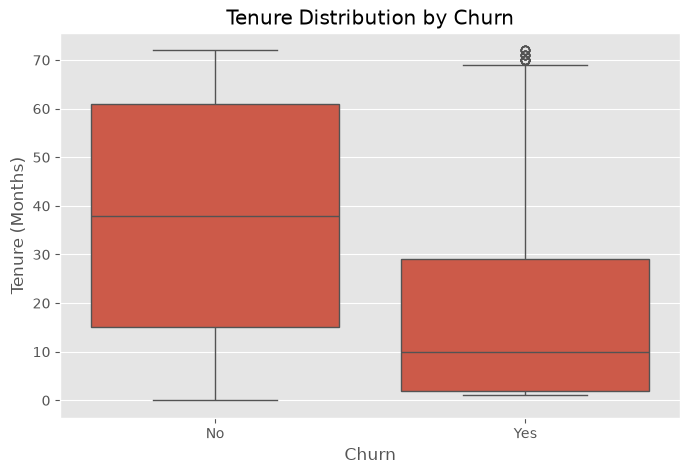

In [16]:
plt.figure(figsize=(8,5))

sns.boxplot(
    data=data,
    x="Churn",
    y="tenure"
)

plt.title("Tenure Distribution by Churn")
plt.xlabel("Churn")
plt.ylabel("Tenure (Months)")

plt.show()

Customers with shorter tenure are more likely to churn. The median tenure of churned customers is only 10 months, compared to 38 months for customers who stayed. Additionally, 75% of churned customers leave within the first 29 months, suggesting that the highest churn risk occurs during the early stages of the customer lifecycle.

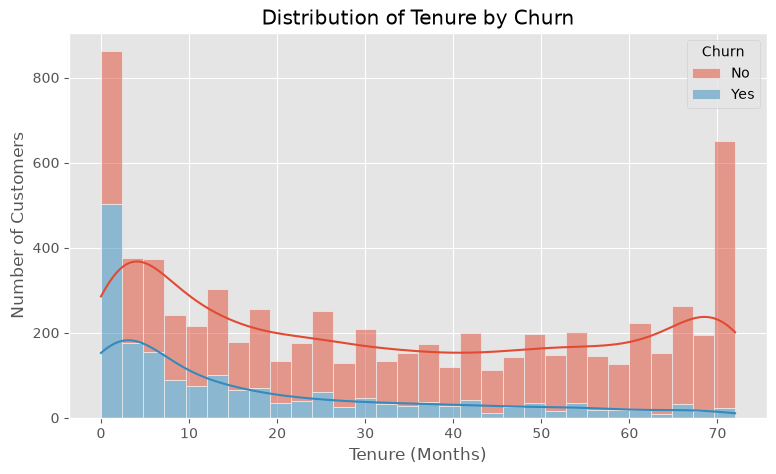

In [17]:
plt.figure(figsize=(9,5))

sns.histplot(
    data=data,
    x="tenure",
    hue="Churn",
    bins=30,
    kde=True,
    multiple="stack"
)

plt.title("Distribution of Tenure by Churn")
plt.xlabel("Tenure (Months)")
plt.ylabel("Number of Customers")

plt.show()

Q. Does the type of contract (Month-to-month, One year, Two year) affect customer churn?

In [20]:
pd.crosstab(data["Contract"], data["Churn"])

Churn,No,Yes
Contract,,
Month-to-month,2220,1655
One year,1307,166
Two year,1647,48


Month-to-month contracts have the highest number of churned customers (1655).   
One-year contracts have far fewer churned customers (166).   
Two-year contracts have the fewest churned customers (48).   

In [24]:
pd.crosstab(
    data["Contract"],
    data["Churn"],
    normalize="index"
) * 100


Churn,No,Yes
Contract,,
Month-to-month,57.290323,42.709677
One year,88.730482,11.269518
Two year,97.168142,2.831858


Customers with long-term contracts are much less likely to churn than customers on month-to-month plans.

Contract type appears to be a strong predictor of customer churn. Customers on month-to-month contracts exhibit a significantly higher churn rate (42.7%) compared to customers with one-year (11.3%) and two-year (2.8%) contracts. This suggests that longer contract commitments are associated with improved customer retention.

Q. Does having Tech Support reduce customer churn?

Customers who have access to Tech Support may be less likely to churn because service issues can be resolved more effectively, leading to greater customer satisfaction and loyalty.

In [25]:
pd.crosstab(data["TechSupport"], data["Churn"])

Churn,No,Yes
TechSupport,,
No,2027,1446
No internet service,1413,113
Yes,1734,310


In [26]:
pd.crosstab(
    data["TechSupport"],
    data["Churn"],
    normalize="index"
) * 100

Churn,No,Yes
TechSupport,,
No,58.364526,41.635474
No internet service,92.595020,7.404980
Yes,84.833659,15.166341


Customers who have Tech Support show a lower churn rate, whereas customers without Tech Support have a much higher churn rate. This suggests that Tech Support may play an important role in improving customer retention.

Customers with Tech Support exhibit a much lower churn rate than customers without Tech Support.

The percentage of customers who churn is significantly higher among those without Tech Support.

This suggests that providing effective technical assistance may improve customer satisfaction and reduce customer churn.



Tech Support appears to be a valuable predictive feature and should be retained for model training.

Q. Does Tech Support reduce churn for each Contract type?

In [28]:
pd.crosstab(data["Contract"], data["TechSupport"], normalize="index") * 100

TechSupport,No,No internet service,Yes
Contract,,,
Month-to-month,69.161290,13.522581,17.316129
One year,37.813985,24.711473,37.474542
Two year,13.923304,37.640118,48.436578


In [30]:
pd.crosstab(
    [data["Contract"], data["TechSupport"]],
    data["Churn"],
    normalize="index"
) * 100

Churn                                      No        Yes
Contract       TechSupport                              
Month-to-month No                   49.626866  50.373134
               No internet service  81.106870  18.893130
               Yes                  69.299553  30.700447
One year       No                   85.278276  14.721724
               No internet service  97.527473   2.472527
               Yes                  86.413043  13.586957
Two year       No                   94.067797   5.932203
               No internet service  99.216301   0.783699
               Yes                  96.467722   3.532278

Based on the current analysis, we only have evidence for this specific customer segment. We cannot conclude that Tech Support reduces churn for every customer without analyzing the other groups.

In [33]:
data.groupby("Churn")["MonthlyCharges"].describe()

,count,mean,std,min,25%,50%,75%,max
Churn,,,,,,,,
No,5174.0,61.265124,31.092648,18.25,25.10,64.425,88.4,118.75
Yes,1869.0,74.441332,24.666053,18.85,56.15,79.650,94.2,118.35


Customers who churn pay higher monthly charges on average than customers who stay.

Customers paying higher monthly charges may look for cheaper alternatives and switch providers.

MonthlyCharges appears to have a relationship with churn and is therefore likely to be a useful predictive feature for the machine learning model.

In [37]:
data.groupby("Churn")["TotalCharges"].describe()

,count,mean,std,min,25%,50%,75%,max
Churn,,,,,,,,
No,5174.0,2549.911442,2329.954215,0.00,572.9,1679.525,4262.85,8672.45
Yes,1869.0,1531.796094,1890.822994,18.85,134.5,703.550,2331.30,8684.80


In [38]:
numeric_df = data.select_dtypes(include=['int64', 'float64'])

numeric_df.corr()

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges
SeniorCitizen,1.000000,0.016567,0.220173,0.103006
tenure,0.016567,1.000000,0.247900,0.826178
MonthlyCharges,0.220173,0.247900,1.000000,0.651174
TotalCharges,0.103006,0.826178,0.651174,1.000000


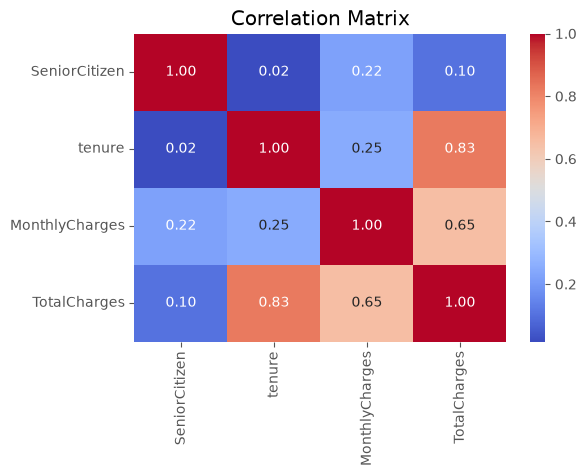

In [39]:
plt.figure(figsize=(6,4))

sns.heatmap(
    numeric_df.corr(),
    annot=True,
    cmap='coolwarm',
    fmt='.2f'
)

plt.title("Correlation Matrix")
plt.show()

The correlation analysis shows that TotalCharges has a strong positive correlation (0.83) with Tenure, indicating that customers who stay longer tend to accumulate higher total charges. MonthlyCharges also has a moderate positive correlation (0.65) with TotalCharges, suggesting that both the monthly bill and the duration of service contribute to the customer's cumulative spending. The weak correlation (0.25) between Tenure and MonthlyCharges indicates that customers with longer service do not necessarily pay higher monthly charges. Overall, no perfectly correlated features were observed, so all numerical features are retained for model training.

EDA Summary

Approximately 26.5% of customers have churned.   
Customers with lower tenure are more likely to churn.   
Month-to-month contracts have the highest churn rate.   
Churned customers pay higher monthly charges but have lower total charges due to shorter tenure.   
Tech Support is associated with lower churn.   
Contract, Tenure, and MonthlyCharges appear to be the most influential features based on exploratory analysis.   
